In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

### Problem 1 : Admission predict Dataset

Using the supplied predictive variables (GRE score, TOEFL score, University Rating, etc.) in the given dataset and predict the admission chance of a new candidate using Linear Regression.


1. Divide the data into the train-test split of 80:20.
2. Implement the Linear Regression Model to Predict the chances of admission.
3. Implement the Gradient Descent with SSE to Optimize the model for up to 100 iterations and predict the test set.
4. Print the Coefficients of the Optimized model.
5. Print the SSE, MSE, and R2 scores for the Train and Test Sets.

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datascience Lab 7/For Assignment 7 Admission_Predict_.csv', index_col="Serial No.")
df.head(2)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76


In [3]:
# 1. Divide the data into the train-test split of 80:20.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Chance of Admit'])
y = df['Chance of Admit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [4]:
# 2. Implement the Linear Regression Model to Predict the chances of admission.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def sum_of_squared_error(y_gt, y_pred):
  return np.sum((y_gt - y_pred)**2)

reg = LinearRegression().fit(X_train, y_train)

print("Linear Regression Coefficients : ")
print("Intercept :", reg.intercept_)
print("Weight :", reg.coef_)

y_train_pred = reg.predict(X_train)
print("\n\nTrain Sum of squared error: ", sum_of_squared_error(y_train, y_train_pred))
print("Train Mean squared error: ", mean_squared_error(y_train, y_train_pred))
print("Train R2 score: ", r2_score(y_train, y_train_pred))

y_test_pred = reg.predict(X_test)
print("\n\nTest Sum of squared error: ", sum_of_squared_error(y_test, y_test_pred))
print("Test Mean squared error: ", mean_squared_error(y_test, y_test_pred))
print("Test R2 score: ", r2_score(y_test, y_test_pred))

Linear Regression Coefficients : 
Intercept : 0.7241749999999999
Weight : [0.02667052 0.01822633 0.00293995 0.001788   0.0158655  0.06758106
 0.01194049]


Train Sum of squared error:  1.4106221913823032
Train Mean squared error:  0.003526555478455758
Train R2 score:  0.8210671369321554


Test Sum of squared error:  0.37046553987884134
Test Mean squared error:  0.0037046553987884136
Test R2 score:  0.8188432567829627


Loss:  2876.826688492033
Loss:  2144.629280604983
Loss:  1620.9827375840555
Loss:  1234.1349825890838
Loss:  943.2800299452183
Loss:  722.5485503098926
Loss:  554.2014735225634
Loss:  425.4619530377279
Loss:  326.86377828051684
Loss:  251.28373728339588
Loss:  193.31627360292583
Loss:  148.84035181638748
Loss:  114.70615869455109
Loss:  88.502686033028
Loss:  68.38284044577661
Loss:  52.930787903408344
Loss:  41.060880260848805
Loss:  31.940445967986925
Loss:  24.930720952661297
Loss:  19.541616162762097
Loss:  15.397060637985158
Loss:  12.20843750411775
Loss:  9.75421780165688
Loss:  7.864343159000841
Loss:  6.408248277850834
Loss:  5.285673843171872
Loss:  4.419619047480086
Loss:  3.750934924387196
Loss:  3.2341761080414395
Loss:  2.8344178375078135
Loss:  2.5248133905058383
Loss:  2.284719536957419
Loss:  2.0982577810889067
Loss:  1.9532099681081956
Loss:  1.8401704557186744
Loss:  1.751895168262938
Loss:  1.682801746736701
Loss:  1.6285856659079685
Loss:  1.585925365117153
Loss:  1

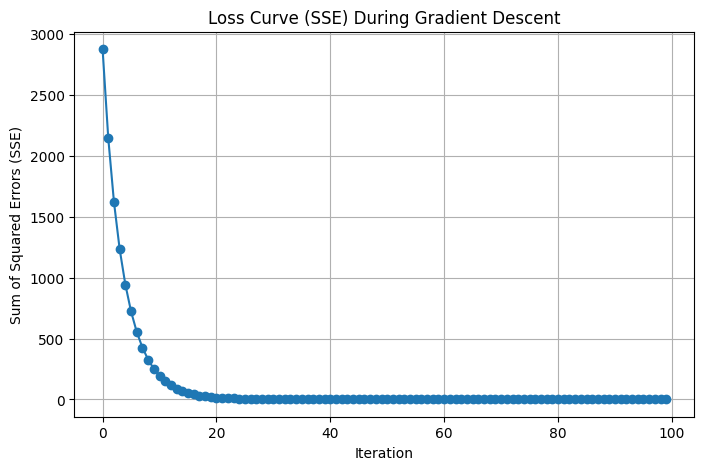

In [5]:
# 3. Implement the Gradient Descent with SSE to Optimize the model for up to 100 iterations and predict the test set.
# Hypothesis function y = m*x + c

def gradient_descent_with_sse_optimier(X, y, lr=0.0005, iterations=100):

  # Initilize params m,c
  n_samples, n_features = X.shape
  m = np.random.rand(n_features)
  c = np.random.rand()
  losses = []

  for i in range(iterations):
    # Prediction
    y_pred = np.dot(X, m) + c

    # Loss
    loss = (y - y_pred) ** 2

    errors = y_pred - y
    dL_dm = 2.0 * np.dot(X.T, errors)
    dL_dc = 2.0 * np.sum(errors)

    m = m - lr* dL_dm
    c = c - lr*dL_dc

    print("Loss: ", np.sum(loss))
    losses.append(np.sum(loss))

  return m, c, losses

# 4. Print the Coefficients of the Optimized model.
m, c, losses = gradient_descent_with_sse_optimier(X_train, y_train)
print("Slope :", m)
print("Intercept :", c)

plt.figure(figsize=(8,5))
plt.plot(losses, marker='o')
plt.title("Loss Curve (SSE) During Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.grid(True)
plt.show()

In [6]:
# 5. Print the SSE, MSE, and R2 scores for the Train and Test Sets.

y_test_pred = np.dot(X_test, m) + c
print("Test Sum of squared error: ", sum_of_squared_error(y_test, y_test_pred))
print("Test Mean squared error: ", mean_squared_error(y_test, y_test_pred))
print("Test R2 score: ", r2_score(y_test, y_test_pred))

Test Sum of squared error:  0.3697118997808577
Test Mean squared error:  0.003697118997808577
Test R2 score:  0.8192117849482359


### Problem 2 :

- Step 1: Define input array X with angles from 60 deg to 360 deg converted in radians.
- Step 2: Compute Y as Y=[Sin(X)+Cos(X)] + K^2 where K is a random number generated from normal distribution with 0.5 mean and 0.15 std dev.
- Step 3: Create Linear Regression model with SSE as error, and different Non-Linear Regression models of 3, 13th and 15th degree polynomials on data created in step-1 and step-2. (You may optimize the model for max. of 100 iterations using Gradient Descent or you may change max.  iterations as needed to get better result).
- Step 4: Plot the created models for the power of 1, 3,13, 15, and print the SSE, Coefficients for the plotted models, and print the prediction of test set on 15th Deg. Polynomial model.
- Step 5: Add the L2 regularization to the nonlinear regression model with 15th degree polynomial created in Step 3. (Optimize for Max. of 50 Iterations and lambda values  [1e-10 and 1e-5])
- Step 6: Plot the Ridge (L2) regression models for lambda values [1e-10 and 1e-5] and print the SSE, Coefficients for the plotted models, and print the prediction of test set on 15th Deg. Polynomial model

 | Iteration : 0 | Loss:  813.626084615842 |
 | Iteration : 3 | Loss:  565.3494096362078 |
 | Iteration : 6 | Loss:  414.3050714054609 |
 | Iteration : 9 | Loss:  322.41272087728174 |
 | Iteration : 12 | Loss:  266.50591059453757 |
 | Iteration : 15 | Loss:  232.49116972448542 |
 | Iteration : 18 | Loss:  211.79463639356044 |
 | Iteration : 21 | Loss:  199.20034154818848 |
 | Iteration : 24 | Loss:  191.53511378122164 |
 | Iteration : 27 | Loss:  186.86853196023077 |
 | Iteration : 30 | Loss:  184.02621079812985 |
 | Iteration : 33 | Loss:  182.29370471669648 |
 | Iteration : 36 | Loss:  181.23637568539831 |
 | Iteration : 39 | Loss:  180.5898085578604 |
 | Iteration : 42 | Loss:  180.19314447327835 |
 | Iteration : 45 | Loss:  179.94852376362917 |
 | Iteration : 48 | Loss:  179.7964127618418 |
 | Iteration : 51 | Loss:  179.70059369251163 |
 | Iteration : 54 | Loss:  179.63903316664926 |
 | Iteration : 57 | Loss:  179.59832696641962 |
 | Iteration : 60 | Loss:  179.57032049097822 |
 |

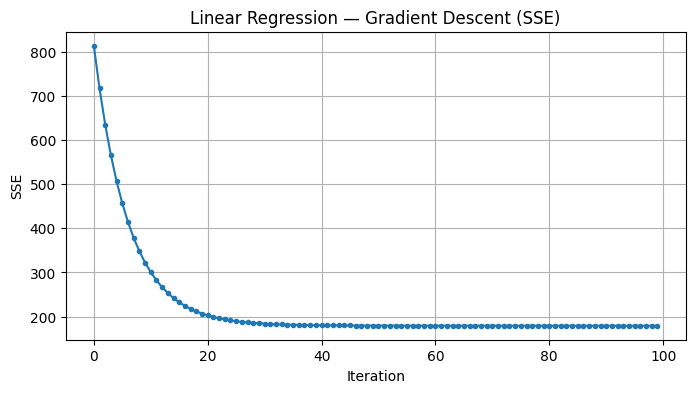

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.46865e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split

# Step 1: Define input array X with angles from 60 deg to 360 deg converted in radians.
array = np.arange(60, 361, 1)
X = np.radians(array)
X = np.expand_dims(X, axis=1)

# Step 2: Compute Y as Y=[Sin(X)+Cos(X)] + K^2 where K is a random number generated
# from normal distribution with 0.5 mean and 0.15 std dev.
np.random.seed(23)
k = np.random.normal(loc=0.5, scale=0.15, size=len(X))
y = (np.sin(X.ravel()) + np.cos(X.ravel())) + k**2

# Step 3: Create Linear Regression model with SSE as error, and different Non-Linear
# Regression models of 3, 13th and 15th degree polynomials on data created in step-1 and
# step-2. (You may optimize the model for max. of 100 iterations using Gradient Descent
# or you may change max. iterations as needed to get better result).

def gradient_descent_with_sse_optimier(X, y, lr=0.00001, iterations=100):
  # Initilize params m,c
  n_samples, n_features = X.shape

  m = np.random.rand(n_features)
  c = np.random.rand()
  losses = []

  for i in range(iterations):
    # Prediction
    y_pred = np.dot(X, m) + c
    errors = y_pred - y

    # Loss
    loss = np.sum(errors**2)
    losses.append(np.sum(loss))
    if i % 3 == 0:
      print(" | Iteration :", i,"| Loss: ", loss, "|")

    # Clalculate & Update
    dL_dm = 2.0 * np.dot(X.T, errors)
    dL_dc = 2.0 * np.sum(errors)

    m = m - lr* dL_dm
    c = c - lr*dL_dc

  return m, c, losses


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

idx = np.argsort(X_test.ravel())
X_test, y_test = X_test[idx], y_test[idx]

m, c, losses = gradient_descent_with_sse_optimier(X_train, y_train)

print('='*40)
print("Linear model (GD) slope:", m, "intercept:", c)
print("Final SSE (train):", losses[-1])
print('='*40)

plt.figure(figsize=(8,4))
plt.plot(losses, marker='o', markersize=3)
plt.title("Linear Regression — Gradient Descent (SSE)")
plt.xlabel("Iteration")
plt.ylabel("SSE")
plt.grid(True)
plt.show()

# --- Polynomial models using SGDRegressor ---
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

degrees = [ 1, 3, 13, 15] # 1 : Linear Model, 3,13,15 : Non-Linear Model
colors = ['purple', 'red', 'orange', 'green']
models = []
X_test_poly_features = []

for degree in degrees:
  poly_features = PolynomialFeatures(degree=degree, include_bias=False)
  X_poly = poly_features.fit_transform(X_train)
  X_test_poly = poly_features.transform(X_test)

  model = Ridge()
  model.fit(X_poly, y_train)

  models.append(model)
  X_test_poly_features.append(X_test_poly)

Degree of the model: 1
SSE : 48.29300641434315
Model Coefficients [-0.18606251]
Degree of the model: 3
SSE : 3.0117899959217067
Model Coefficients [-0.92343692 -0.25669472  0.05932825]
Degree of the model: 13
SSE : 1.2380948574627557
Model Coefficients [-1.52613639e-02 -2.96816975e-02 -4.06224762e-02 -4.24654150e-02
 -2.64448866e-02  7.07569005e-03  2.19007181e-02 -1.67612912e-02
  5.84675507e-03 -1.18754598e-03  1.44837363e-04 -9.86400450e-06
  2.88740360e-07]
Degree of the model: 15
SSE : 1.2465530573105952
Model Coefficients [-2.28387595e-02 -3.90002732e-02 -4.19375944e-02 -2.94774646e-02
 -9.40357326e-03  2.37800221e-03 -1.11674326e-03 -2.41688848e-03
  8.06370948e-03 -6.30113079e-03  2.39905446e-03 -5.19352711e-04
  6.55660990e-05 -4.51710644e-06  1.31676498e-07]


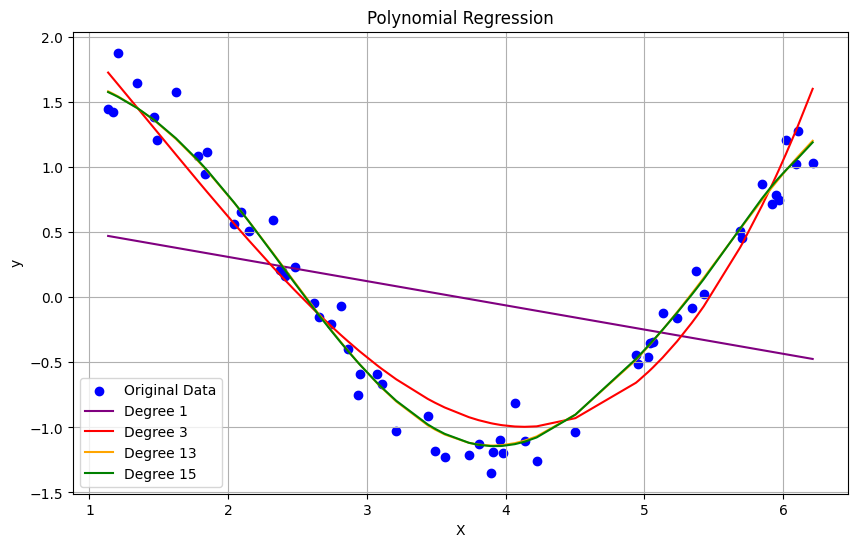

Prediction of test set using 15 degree polynomialn model
[ 1.57601622  1.55853561  1.53993961  1.45378936  1.36209649  1.34771416
  1.22104359  1.05456211  0.99380122  0.97300311  0.72835401  0.65736251
  0.58496671  0.33672975  0.26118747  0.23598809  0.21079561  0.11028713
 -0.08753421 -0.13590698 -0.25421728 -0.34566762 -0.41209417 -0.4974523
 -0.51817882 -0.65579097 -0.69255687 -0.79550129 -0.97720331 -1.01043315
 -1.04932672 -1.11814226 -1.13377209 -1.14337259 -1.14394789 -1.14295896
 -1.14172146 -1.12871332 -1.11015969 -1.07696911 -0.90198564 -0.47466811
 -0.45501564 -0.37487533 -0.35446033 -0.33389248 -0.25005747 -0.11927947
  0.01830639  0.0658239   0.13870298  0.526287    0.55268205  0.75757995
  0.85174158  0.89578697  0.91698681  0.97735082  1.05184482  1.06998491
  1.18984205]


In [8]:
# Step 4: Plot the created models for the power of 1, 3, 13, 15, and print the SSE,
# Coefficients for the plotted models, and print the prediction of test set on 15th Deg. Polynomial model.

def sum_of_squared_error(y_gt, y_pred):
  return np.sum((y_gt - y_pred)**2)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Original Data')

for i, (model, X_test_poly, color) in enumerate(zip(models, X_test_poly_features, colors)):
  y_pred = model.predict(X_test_poly)
  sse = sum_of_squared_error(y_test, y_pred)
  print("Degree of the model:", degrees[i])
  print("SSE :", sse)
  print("Model Coefficients", model.coef_)

  plt.plot(X_test, y_pred, color=color, label=f'Degree {degrees[i]}')
  print("="*40)
plt.title(f'Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print("="*40)
print("Prediction of test set using 15 degree polynomialn model")
model_deg_15 = models[3]
X_test_poly = X_test_poly_features[3]
y_pred = model.predict(X_test_poly)
print(y_pred)

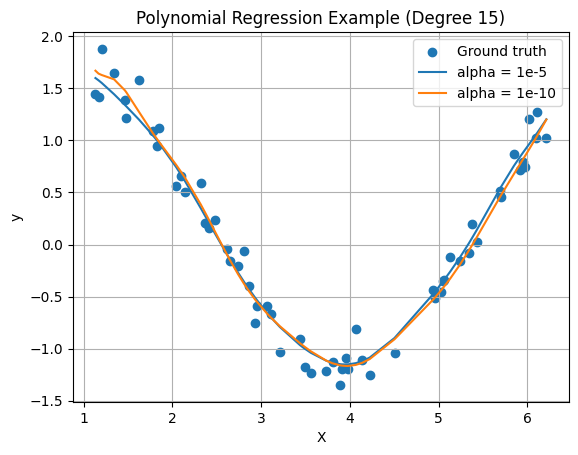

In [9]:
# Step 5: Add the L2 regularization to the nonlinear regression model with
# 15th degree polynomial created in Step 3. (Optimize for Max. of 50 Iterations
# and lambda values [1e-10 and 1e-5])

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDRegressor

poly_features = PolynomialFeatures(degree=15, include_bias=False)
X_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

model_1 = Ridge(max_iter=100, alpha=1e-5)
model_1.fit(X_poly, y_train)
y_pred_1 = model_1.predict(X_test_poly)

model_2 = Ridge(max_iter=100, alpha=1e-10)
model_2.fit(X_poly, y_train)
y_pred_2 = model_2.predict(X_test_poly)

plt.scatter(X_test, y_test, label=f'Ground truth')
plt.plot(X_test, y_pred_1, label=f'alpha = 1e-5')
plt.plot(X_test, y_pred_2, label=f'alpha = 1e-10')
plt.title(f'Polynomial Regression Example (Degree {degrees[i]})')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()